# Tarefa 2: Modelos de Classificação

Treinamento e comparação de cinco algoritmos de classificação para distinguir variedades de grãos de trigo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

BASE_DIR = Path('..')
DATA_DIR = BASE_DIR / 'data' / 'processed'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'seeds_train.csv')
test = pd.read_csv(DATA_DIR / 'seeds_test.csv')

features = [c for c in train.columns if c != 'variety']
X_train, y_train = train[features], train['variety']
X_test, y_test = test[features], test['variety']

print('Treino:', X_train.shape, 'Teste:', X_test.shape)

Treino: (147, 7) Teste: (63, 7)


## Modelos base

In [2]:
models = {
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = model
    
    results.append({
        'Modelo': name,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Acurácia', ascending=False)
results_df.round(4)

,Modelo,Acurácia,Precisão,Recall,F1-score
4,Logistic Regression,0.9048,0.9048,0.9048,0.9048
0,KNN,0.8889,0.8887,0.8889,0.8885
1,SVM,0.8889,0.8887,0.8889,0.8885
2,Random Forest,0.8413,0.8415,0.8413,0.8402
3,Naive Bayes,0.8413,0.8415,0.8413,0.8402


## Relatórios detalhados

In [3]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, zero_division=0))


=== KNN ===
              precision    recall  f1-score   support

    Canadian       0.86      0.90      0.88        21
        Kama       0.85      0.81      0.83        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63


=== SVM ===
              precision    recall  f1-score   support

    Canadian       0.86      0.90      0.88        21
        Kama       0.85      0.81      0.83        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63


=== Random Forest ===
              precision    recall  f1-score   support

    Canadian       0.78      0.86      0.82        21
        Kama       0.79      0.71      0.75        21
        Rosa       0.95   

## Matrizes de confusão

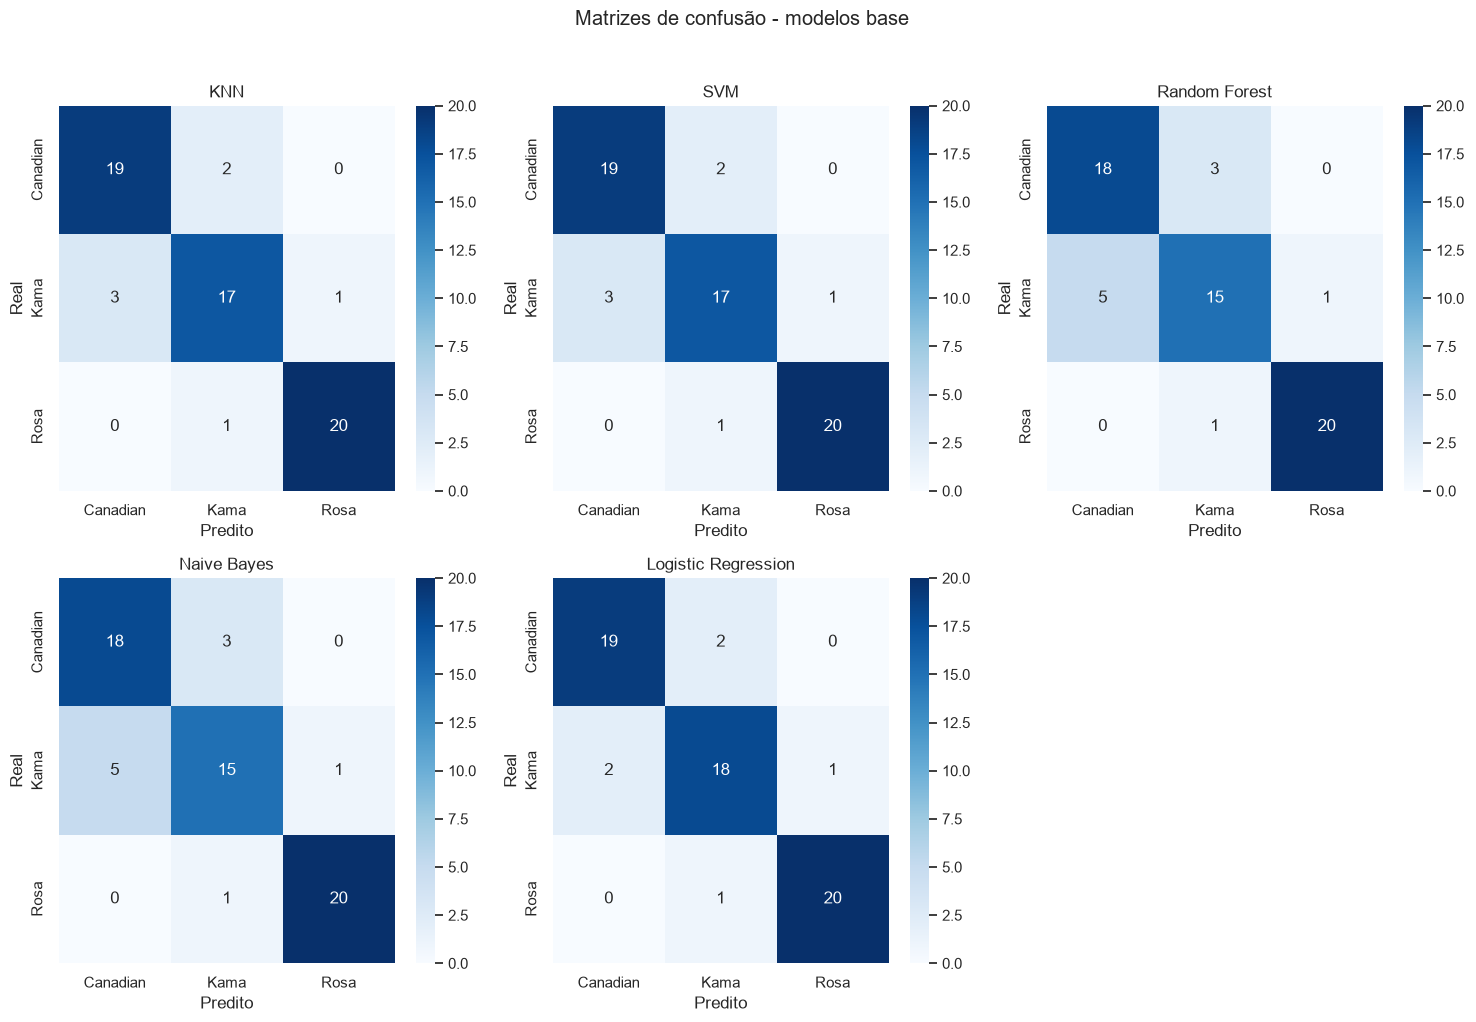

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
classes = sorted(y_test.unique())

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=axes[idx])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predito')
    axes[idx].set_ylabel('Real')

axes[-1].axis('off')
plt.suptitle('Matrizes de confusão - modelos base', y=1.02)
plt.tight_layout()
plt.show()

## Comparação visual das métricas

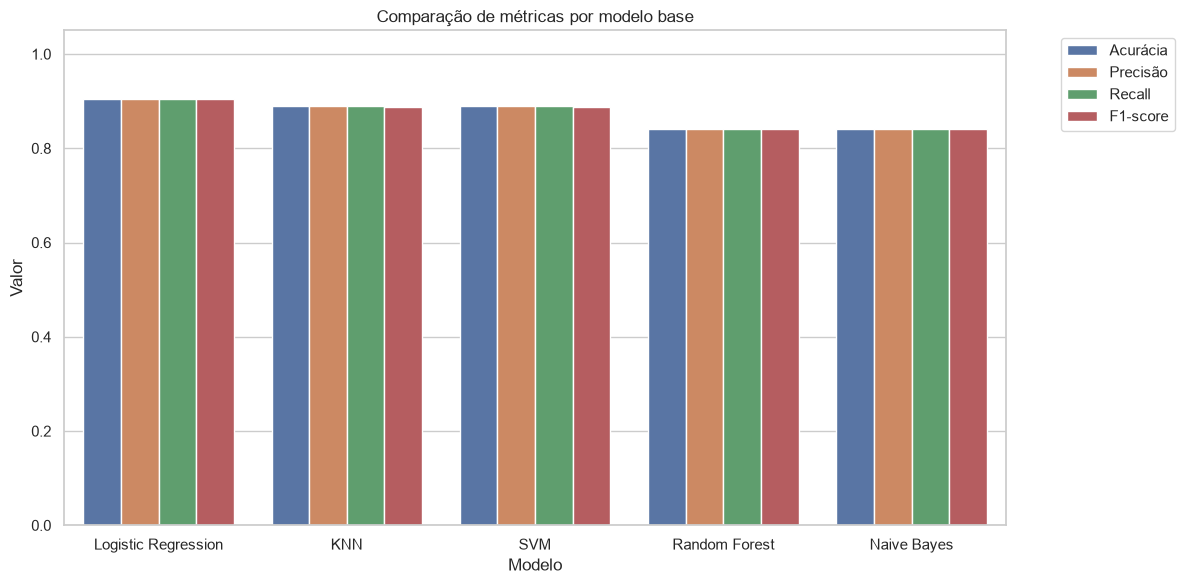

In [5]:
metrics_melted = results_df.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')
plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_melted, x='Modelo', y='Valor', hue='Métrica')
plt.ylim(0, 1.05)
plt.title('Comparação de métricas por modelo base')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Salvar modelos base

In [6]:
for name, model in trained_models.items():
    safe_name = name.lower().replace(' ', '_')
    joblib.dump(model, MODELS_DIR / f'{safe_name}_base.pkl')
    
print('Modelos base salvos em', MODELS_DIR)

Modelos base salvos em ..\models
